In [1]:
import os
import boto3
import pickle
import shutil
from pprint import pprint
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

try:
    import catboost
except:
    ! pip install catboost

### Constants

In [2]:
str_project = '20231010-gen-xii'
str_dirname_output = './output'
str_variant = 'noPTImodel10'

### Create output directory

In [3]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

### Create variant directory

In [4]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except FileExistsError:
    pass

### Load dictionary of output

In [5]:
str_filename = 'dict_output.pkl'
str_local_path = f'../../05_parser/02_codebtor/output/{str_variant}/{str_filename}'
dict_output = pd.read_pickle(str_local_path)
# print keys
pprint(dict_output.keys())

dict_keys(['str_tiers', 'list_unique_id', 'flt_sec_get_data', 'X_raw', 'flt_sec_preprocessing', 'X_clean', 'flt_sec_predictions', 'y_hat_ad', 'mean_ad', 'y_hat_pd', 'mean_pd', 'y_hat_lgd', 'mean_lgd', 'ecnl', 'ecnl_mod', 'flt_sec_adverse_action', 'df_shap_vals', 'list_list_reasons', 'flt_sec_counters', 'df_counter_offers', 'flt_apr', 'flt_net_discount', 'flt_sec_generate_output', 'output_final'])


### Get data

In [6]:
pprint(dict_output['list_unique_id'])

[800484299135421, 800484299135430]


In [7]:
# time
flt_sec_get_data = dict_output['flt_sec_get_data']
print(f'Time to get data: {flt_sec_get_data:0.9f} sec.')

Time to get data: 0.173230600 sec.


### Shared preprocessing

In [8]:
dict_output['X_clean']

,uniqueid__app,bigaccountid__app,bigdebtorid__app,bankruptcycount24month__ln,inquiryshortterm12month__ln,re01s__tu,bankruptcystatus__ln,bankruptcytimenewest__ln,fltgrossmonthly__income_sum,linka006__tu,...,intservicecontractmileage__app,fltapprovedservicecontract__app,fltgapinsurance__app,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,800484299135421,8004842,9913542,0.0,0.0,0.0,0.0,0.0,9500.0,0.0,...,120000.0,0.0,0.0,2024,0.9409,10,4,0.931034,7.0,21.265753
0,800484299135430,8004842,9913543,0.0,0.0,0.0,0.0,0.0,19000.0,0.0,...,120000.0,0.0,0.0,2024,0.9409,10,4,0.931034,7.0,21.265753


In [9]:
# time
flt_sec_preprocessing = dict_output['flt_sec_preprocessing']
print(f'Time to preprocess: {flt_sec_preprocessing:0.9f} sec.')

Time to preprocess: 0.522142400 sec.


### Generate predictions

In [10]:
pprint(dict_output['y_hat_pd'])

0    0.199744
1    0.197792
dtype: float64


In [11]:
pprint(dict_output['y_hat_lgd'])

0    0.681574
1    0.679959
dtype: float64


In [12]:
pprint(dict_output['ecnl'])

0.13531482938797976


In [13]:
pprint(dict_output['ecnl_mod'])

0.3193429973556322


In [14]:
# time
flt_sec_predictions = dict_output['flt_sec_predictions']
print(f'Time to generate predictions: {flt_sec_predictions:0.9f} sec.')

Time to generate predictions: 0.029402300 sec.


### Adverse action

In [15]:
dict_output['df_shap_vals']

,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,alertregulatorycondition__ln,bc97b__tu,...,agg903__tu,ret205__tu,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app
0,-0.273614,0.164510,-0.014038,0.057504,-0.007289,-0.023523,-0.124753,0.038199,0.0062,0.01339,...,-0.004162,0.022093,0.008264,0.000313,-0.005242,0.018679,0.000748,0.03499,-0.124472,-0.100923
0,-0.270248,0.165939,-0.014326,0.055473,-0.000080,-0.023523,-0.123351,0.038199,0.0062,0.01339,...,-0.004162,0.022093,0.008264,0.000313,-0.005242,0.018679,0.000748,0.03499,-0.124472,-0.100923


In [16]:
dict_output['list_list_reasons']

[['Insufficient credit file, Length of Credit',
  'Derogatory public record',
  'Derogatory public record',
  'Insufficient credit file, Length of Credit',
  'Insufficient property value'],
 ['Insufficient credit file, Length of Credit',
  'Derogatory public record',
  'Derogatory public record',
  'Insufficient credit file, Length of Credit',
  'Insufficient property value']]

In [17]:
# time
flt_sec_adverse_action = dict_output['flt_sec_adverse_action']
print(f'Time to generate adverse action: {flt_sec_adverse_action:0.9f} sec.')

Time to generate adverse action: 0.170279100 sec.


### Counter offers

In [18]:
dict_output['df_counter_offers']

,Offer,ECNL,Decision,DownCash,AmountFinanced,SalesPrice,APR,NetDiscount,CurrentLTV,MaxLTV
0,0,0.319343,Approved,5000,14528,17200,0.2355,1019.0,0.932897,0.932897
3,3,0.279127,Approved,6500,13028,17200,0.2355,359.0,0.836576,0.932897


In [19]:
# time
flt_sec_counter_offers = dict_output['flt_sec_counters']
print(f'Time to generate counter offers: {flt_sec_counter_offers:0.9f} sec.')

Time to generate counter offers: 0.914229400 sec.


### Generate output

In [20]:
pprint(dict_output['output_final'])

{'Request_id': '',
 'Response': [{'CounterOffers': [{'APR': 0.2355,
                                  'AmountFinanced': 14528,
                                  'CurrentLTV': 0.9328966801515444,
                                  'Decision': 'Approved',
                                  'DownCash': 5000,
                                  'ECNL': 0.3193429973556322,
                                  'MaxLTV': 0.9328966801515444,
                                  'NetDiscount': 1019.0,
                                  'Offer': 0,
                                  'SalesPrice': 17200},
                                 {'APR': 0.2355,
                                  'AmountFinanced': 13028,
                                  'CurrentLTV': 0.8365761253451487,
                                  'Decision': 'Approved',
                                  'DownCash': 6500,
                                  'ECNL': 0.27912655262520797,
                                  'MaxLTV': 0.932896680151544

In [21]:
# time
flt_sec_output = dict_output['flt_sec_generate_output']
print(f'Time to generate output: {flt_sec_output:0.9f} sec.')

Time to generate output: 0.009057200 sec.


## Plot

In [22]:
df = pd.DataFrame({
    'step': ['Get Data', 'Preprocessing', 'Predictions', 'Adverse Action', 'Counter Offers', 'Generate Output'],
    'sec': [flt_sec_get_data, flt_sec_preprocessing, flt_sec_predictions, flt_sec_adverse_action, flt_sec_counter_offers, flt_sec_output],
})
flt_time_total = np.sum(df['sec'])
df['prop'] = df['sec'] / flt_time_total
df.to_csv(f'{str_dirname_output}/{str_variant}/df_times.csv', index=False)
print(f'Total time: {flt_time_total} sec.')
print('')
df

Total time: 1.8183410000000002 sec.



,step,sec,prop
0,Get Data,0.173231,0.095268
1,Preprocessing,0.522142,0.287153
2,Predictions,0.029402,0.016170
3,Adverse Action,0.170279,0.093645
4,Counter Offers,0.914229,0.502782
5,Generate Output,0.009057,0.004981


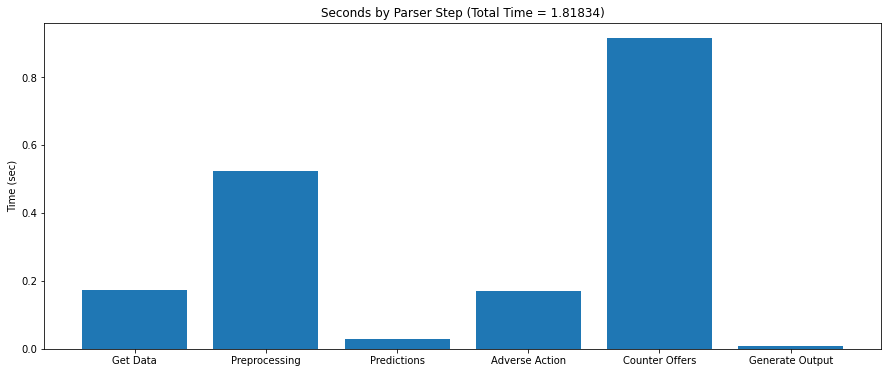

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_title(f'Seconds by Parser Step (Total Time = {flt_time_total:0.5f})')
ax.set_ylabel('Time (sec)')
ax.bar(df['step'], df['sec'])
plt.savefig(f'{str_dirname_output}/{str_variant}/plt_parser_times.png', bbox_inches='tight')
plt.show()

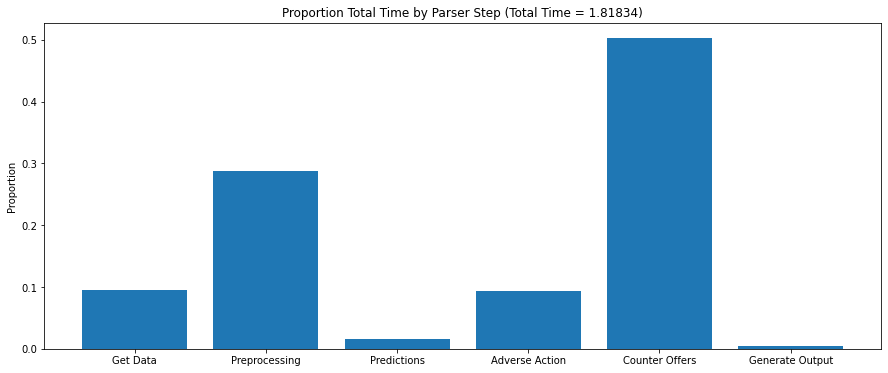

In [24]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_title(f'Proportion Total Time by Parser Step (Total Time = {flt_time_total:0.5f})')
ax.set_ylabel('Proportion')
ax.bar(df['step'], df['prop'])
plt.savefig(f'{str_dirname_output}/{str_variant}/plt_parser_proportions.png', bbox_inches='tight')
plt.show()